# Notebook 01 — Esplorazione dei dati orientata al problema

**Fase 2.a della traccia**: EDA per supportare le scelte di modellistica della Fase 2.b.

> *"L'analisi esplorativa non è un esercizio di stile. Ogni grafico che producete deve rispondere a una domanda."* — Traccia

## Obiettivi didattici

1. Capire la **doppia stagionalità** del traffico cittadino (giornaliera × settimanale × annuale)
2. Misurare l'**eteroschedasticità**: la varianza dipende dall'ora → soglie statiche sono sbagliate
3. Quantificare l'**effetto del meteo** sul flusso
4. Analizzare la **qualità del dato** via accuratezza spire (cuore del progetto)
5. Visualizzare le **festività** come stress-test per il sistema futuro

## Indice

1. Setup e caricamento master dataset
2. Statistiche descrittive di base
3. Stagionalità giornaliera e settimanale
4. Stagionalità annuale (mese × ora)
5. Eteroschedasticità: deviazione standard in funzione del contesto
6. Effetto del meteo (pioggia, temperatura)
7. Qualità del dato: distribuzione dell'accuratezza
8. Festività e tipo giorno
9. Sintesi delle evidenze per la Fase 2.b

## 1. Setup e caricamento master dataset

Importiamo il package `src` come libreria del progetto e carichiamo il dataset master già preprocessato. Tutta la pipeline di download, pulizia e feature engineering è incapsulata in `src/preprocessing.py:carica_master()` — qui ci concentriamo solo sull'analisi.

In [1]:
# Aggiungiamo il root del progetto al path per importare src.*
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import carica_master

config.set_global_seed()  # riproducibilità

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 90

df = carica_master()
print(f'Shape: {df.shape}')
print(f'Periodo: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Spire: {df["chiave"].nunique()}')

[master] da cache (master.parquet)
Shape: (315792, 32)
Periodo: 2024-01-01 00:00:00 → 2025-12-31 23:00:00
Spire: 18


### Identificazione delle spire selezionate

Il preprocessing ha selezionato automaticamente le 18 spire con maggiore qualità del dato. Le elenchiamo per documentazione.

In [2]:
spire_info = (
    df.groupby('chiave')
      .agg(nome_via=('nome_via', 'first'),
           direzione=('direzione', 'first'),
           longitudine=('longitudine', 'first'),
           latitudine=('latitudine', 'first'),
           n_ore=('conteggio_veicoli', 'count'),
           flusso_medio=('conteggio_veicoli', 'mean'))
      .sort_values('flusso_medio', ascending=False)
      .reset_index()
)
spire_info

,chiave,nome_via,direzione,longitudine,latitudine,n_ore,flusso_medio
0,104,VIA CRISTOFORO COLOMBO,N,11.333042,44.527946,17544,860.276672
1,255,VIA PO,N,11.378522,44.475614,17544,397.689453
2,230,VIA GIUSEPPE DOZZA,SE,11.399546,44.473947,17544,359.606201
3,228,VIA GIUSEPPE DOZZA,NO,11.400667,44.473605,17544,336.881683
4,261,VIA GIUSEPPE MEZZOFANTI,O,11.367410,44.482664,17544,253.894775
5,274,VIA S.MAMOLO,N,11.339554,44.486113,17544,220.690781
6,277,VIA S.MAMOLO,N,11.339566,44.486297,17544,185.775360
7,157,VIA FRANCESCO ZANARDI,SE,11.329212,44.509158,17544,170.998627
8,240,VIA PARISIO,O,11.369825,44.472666,17544,166.050552
9,20,VIA S.STEFANO,SE,11.349800,44.490458,17544,159.911880


## 2. Statistiche descrittive di base

### Teoria — Perché iniziamo da qui

Prima di qualunque tecnica avanzata, l'EDA classica deve rispondere a:
- Qual è il **range** dei valori (min, max, percentili)?
- Quanti **dati mancanti** ci sono e dove?
- Esistono **outlier evidenti** già visibili a occhio?

Per anomaly detection, queste domande sono particolarmente importanti perché:
1. Un dataset con il 50% di NaN richiede strategia di imputation prima del modeling
2. Outlier nel training contaminano i modelli (specialmente IsolationForest e LightGBM)
3. Il range osservato definisce le scale di riferimento per le soglie

In [3]:
print('=== Statistiche conteggio veicoli ===')
print(df['conteggio_veicoli'].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))
print()
print(f'Valori NaN: {df["conteggio_veicoli"].isna().sum()} ({df["conteggio_veicoli"].isna().mean():.2%})')
print(f'Valori zero: {(df["conteggio_veicoli"] == 0).sum()} ({(df["conteggio_veicoli"] == 0).mean():.2%})')

=== Statistiche conteggio veicoli ===
count    315792.000000
mean        213.543549
std         265.892151
min           0.000000
1%            0.000000
25%          37.000000
50%         140.000000
75%         273.000000
99%        1453.000000
max        2190.000000
Name: conteggio_veicoli, dtype: float64

Valori NaN: 0 (0.00%)
Valori zero: 18259 (5.78%)


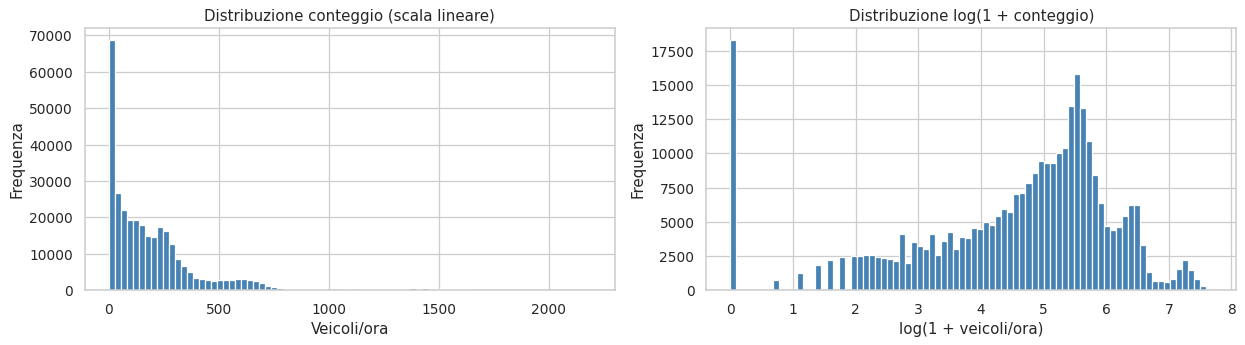

In [4]:
# Distribuzione globale del conteggio in scala logaritmica.
# La scala log è essenziale qui: la distribuzione del traffico orario è
# fortemente skewed (mediana ~50, massimo > 1000). Su scala lineare il
# grosso della distribuzione si addensa vicino allo zero.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['conteggio_veicoli'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione conteggio (scala lineare)')
axes[0].set_xlabel('Veicoli/ora')
axes[0].set_ylabel('Frequenza')

axes[1].hist(np.log1p(df['conteggio_veicoli'].dropna()), bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuzione log(1 + conteggio)')
axes[1].set_xlabel('log(1 + veicoli/ora)')
axes[1].set_ylabel('Frequenza')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '01_distribuzione_conteggio.png', dpi=120)
plt.show()

**Osservazione**: la distribuzione log è **bimodale** — due gobbe distinte. La gobba sinistra corrisponde alle ore notturne (basso traffico), la destra a quelle diurne. Questo conferma che il traffico ha **almeno due regimi distinti** e giustifica l'inclusione dell'ora del giorno come feature condizionante.

## 3. Stagionalità giornaliera e settimanale

### Teoria — Stagionalità multipla

Una serie storica può avere **più stagionalità sovrapposte**:
- **Stagionalità giornaliera** (periodo 24 ore): ciclo veglia/sonno della città
- **Stagionalità settimanale** (periodo 168 ore): differenza lun-ven vs sab-dom
- **Stagionalità annuale** (periodo 8760 ore): estate vs inverno, ferie estive

Riconoscere e modellare queste stagionalità è il primo passo per costruire un detector di anomalie: un'osservazione è "anomala" non rispetto alla media globale, ma rispetto al valore atteso DATO il contesto temporale.

Riferimento: Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, cap. 6 "Time series decomposition".

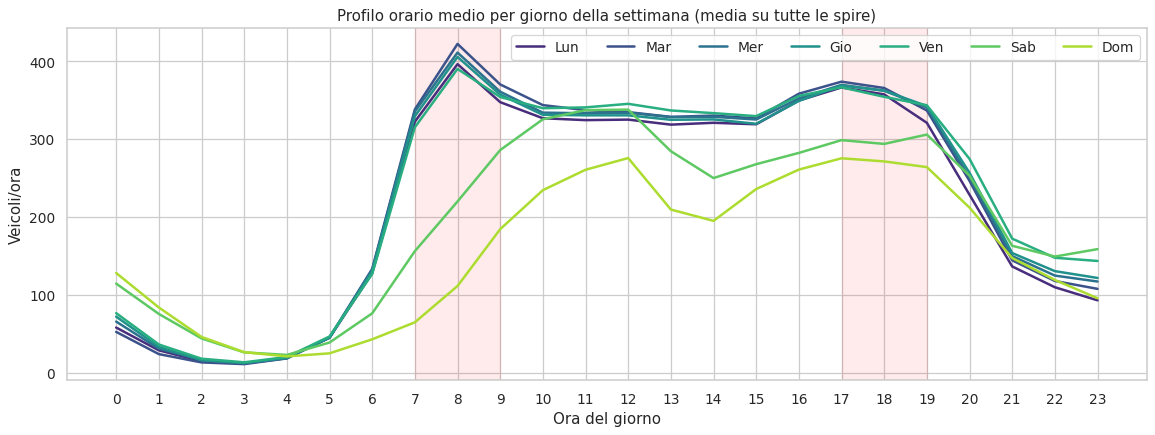

In [5]:
# Profilo orario medio per giorno della settimana.
# Aggregazione: media del conteggio per (giorno_settimana, ora).
# Indicizziamo i giorni in ordine cronologico per la legenda.
ordine_giorni = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
etichette_it = {'Monday': 'Lun', 'Tuesday': 'Mar', 'Wednesday': 'Mer', 'Thursday': 'Gio',
                'Friday': 'Ven', 'Saturday': 'Sab', 'Sunday': 'Dom'}

profilo = (
    df.groupby(['giorno_settimana', 'ora'])['conteggio_veicoli']
      .mean()
      .unstack(level=0)
      [ordine_giorni]
)

fig, ax = plt.subplots(figsize=(13, 5))
colori = sns.color_palette('viridis', n_colors=7)
for i, g in enumerate(ordine_giorni):
    ax.plot(profilo.index, profilo[g], label=etichette_it[g], color=colori[i], linewidth=2)
ax.set_title('Profilo orario medio per giorno della settimana (media su tutte le spire)')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('Veicoli/ora')
ax.set_xticks(range(0, 24))
ax.legend(ncol=7)
ax.axvspan(7, 9, alpha=0.08, color='red', label='ora di punta mattutina')
ax.axvspan(17, 19, alpha=0.08, color='red')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '02_profilo_orario_dow.png', dpi=120)
plt.show()

**Pattern emergenti**:
- **Lun-Ven**: classica "doppia gobba" — picco mattutino 7-9, picco serale 17-19
- **Sabato**: picco mattutino attenuato, picco serale spostato avanti (movida)
- **Domenica**: profilo schiacciato, picco unico nel pomeriggio

Questo è il **prior** del nostro detector: ogni deviazione significativa da questo profilo, **dato il giorno della settimana**, è candidata anomalia.

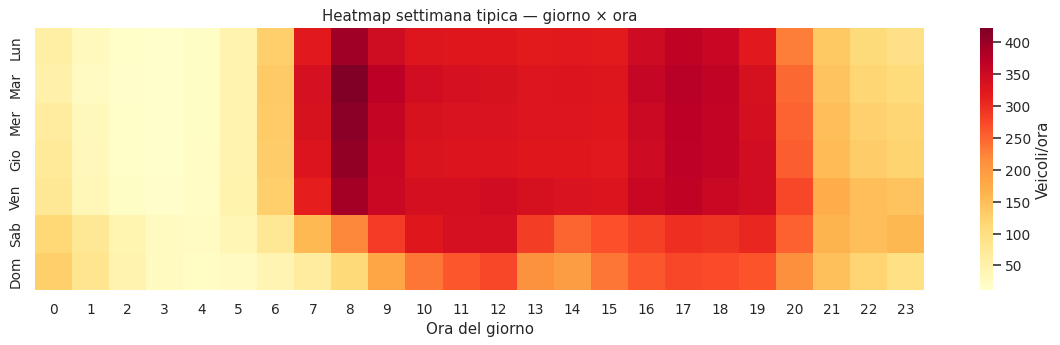

In [6]:
# Heatmap: una vista d'insieme di TUTTE le 168 ore della settimana tipica.
fig, ax = plt.subplots(figsize=(13, 4))
pivot = (
    df.groupby(['giorno_settimana', 'ora'])['conteggio_veicoli']
      .mean().unstack().reindex(ordine_giorni)
)
pivot.index = [etichette_it[g] for g in pivot.index]
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Veicoli/ora'}, ax=ax)
ax.set_title('Heatmap settimana tipica — giorno × ora')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '03_heatmap_settimana.png', dpi=120)
plt.show()

## 4. Stagionalità annuale

### Teoria — Effetto stagione e festività

Oltre alle stagionalità infra-settimanali, esiste un ciclo annuale dovuto a:
- Vacanze estive (Ferragosto e dintorni)
- Festività natalizie
- Anno scolastico (settembre → giugno con pause)
- Cambio di stagione meteorologica (effetti indiretti via comportamento)

Visualizziamo questo ciclo con una heatmap **mese × ora**.

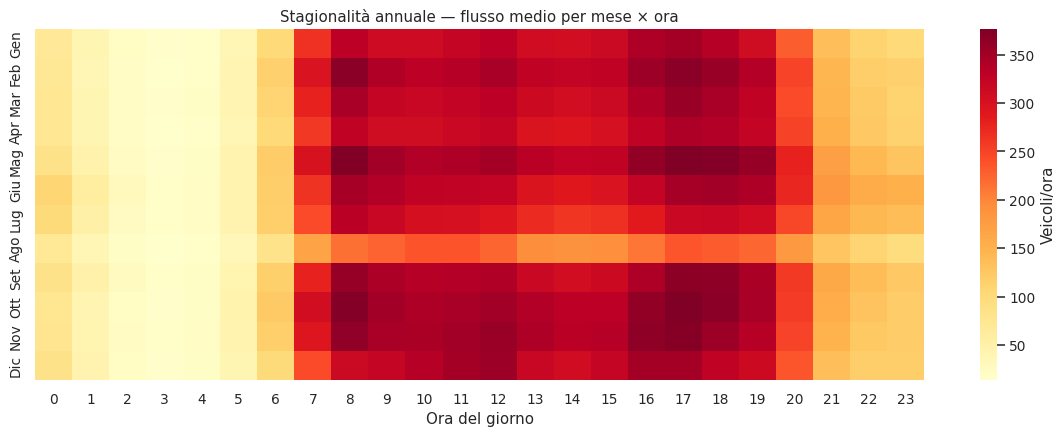

In [7]:
pivot_annuale = (
    df.groupby(['mese', 'ora'])['conteggio_veicoli']
      .mean().unstack()
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_annuale, cmap='YlOrRd', cbar_kws={'label': 'Veicoli/ora'},
            xticklabels=range(24), yticklabels=['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic'], ax=ax)
ax.set_title('Stagionalità annuale — flusso medio per mese × ora')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '04_stagionalita_annuale.png', dpi=120)
plt.show()

**Osservazione chiave**: la riga di **agosto** è marcatamente più chiara — il calo da ferie estive è visibilissimo. La traccia ce lo aveva anticipato:

> *"Il sistema deve flaggare il calo strutturale di traffico ad agosto per le ferie? Probabilmente no, perché è atteso e noto."*

Per assicurarsi che il modello "sappia" che agosto è anomalo **in senso stagionale ma normale in senso strutturale**, includiamo `mese` come feature condizionante nei modelli.

## 5. Eteroschedasticità — la varianza dipende dal contesto

### Teoria — Perché soglie statiche sono sbagliate

**Eteroschedasticità** = la varianza della serie non è costante nel tempo.

Nel nostro caso, alle ore 3 del mattino la deviazione standard del traffico è ~5 veicoli/ora, alle ore 18 è ~150. Significa che:

- Una soglia statica come `|deviation| > 50` è **troppo sensibile** alle 3 (segnalerebbe rumore) e **troppo permissiva** alle 18 (perderebbe anomalie reali).
- Le soglie devono essere **scalate per il contesto**: ad es. `|z| > 3` dove `z = (y - E[y|h]) / σ[y|h]` (z-score condizionato).

Per questo nelle baseline:
- **B1 (STL+MAD)** standardizza i residui via MAD locale
- **B3 (LGBM forecasting)** calcola `(y - ŷ) / σ_residuo` per spira

Visualizziamo l'eteroschedasticità.

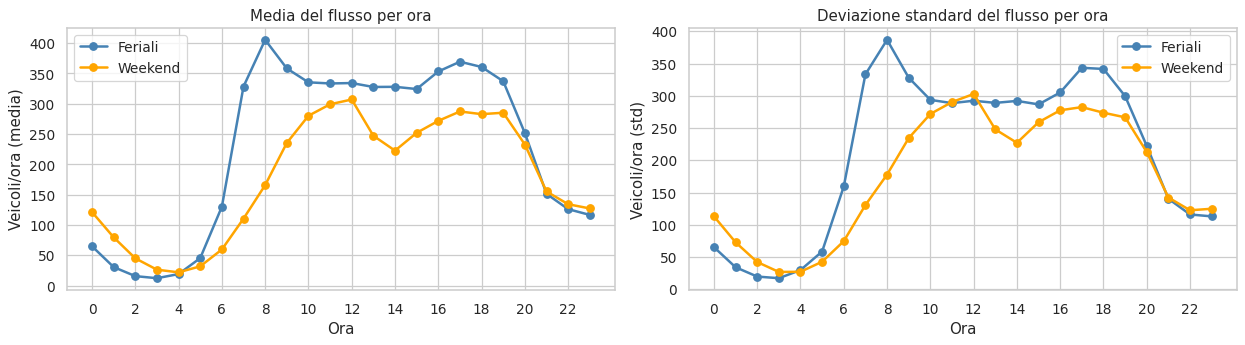

Rapporto max/min della std oraria: 22.5x


In [8]:
# Per ogni ora del giorno, calcoliamo media e std del conteggio.
# Confrontiamo lun-ven (regime "feriale") vs sab-dom (regime "weekend").
stats_ora = (
    df.groupby(['ora', 'weekend'])['conteggio_veicoli']
      .agg(['mean', 'std'])
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for weekend, lbl, color in [(False, 'Feriali', 'steelblue'), (True, 'Weekend', 'orange')]:
    sub = stats_ora[stats_ora['weekend'] == weekend]
    axes[0].plot(sub['ora'], sub['mean'], marker='o', label=lbl, color=color, linewidth=2)
    axes[1].plot(sub['ora'], sub['std'], marker='o', label=lbl, color=color, linewidth=2)
axes[0].set_title('Media del flusso per ora')
axes[0].set_xlabel('Ora')
axes[0].set_ylabel('Veicoli/ora (media)')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))
axes[1].set_title('Deviazione standard del flusso per ora')
axes[1].set_xlabel('Ora')
axes[1].set_ylabel('Veicoli/ora (std)')
axes[1].legend()
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '05_eteroschedasticita.png', dpi=120)
plt.show()

print(f'Rapporto max/min della std oraria: {stats_ora["std"].max() / stats_ora["std"].min():.1f}x')

**Conclusione**: la deviazione standard varia di un fattore ~10x-30x tra le ore notturne e quelle di punta. Confermato: un sistema con soglia globale sarebbe inutile.

## 6. Effetto del meteo

### Teoria — Variabili confondenti e feature engineering

Quando una variabile esterna (qui il meteo) influenza la grandezza che vogliamo monitorare (il traffico), ignorarla significa:
- Confondere effetti meteo con anomalie (un giorno piovoso ridurrà il traffico → potrebbe sembrare anomalo se il modello non lo sa)
- Aumentare i falsi positivi nelle giornate eccezionali (nevicate, ondate di calore)

L'effetto del meteo sul traffico è **non lineare** e **non uniforme tra strade**:
- Pioggia leggera → ↓ ~5-10% del flusso (più persone preferiscono auto al posto di bici/moto, ma la velocità cala)
- Pioggia intensa → comportamento variabile per strada
- Temperatura estrema → ↓ marcato (estate o inverno rigido)

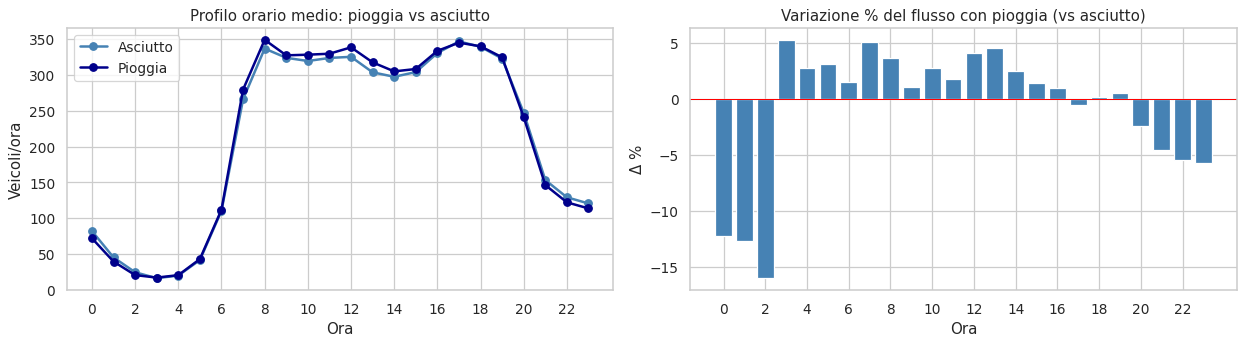

Variazione media giornaliera col piove: -0.8%


In [9]:
# Effetto pioggia. Usiamo solo dati affidabili (acc >= 80%).
df_ok = df[df['accuratezza'] >= 80]
df_ok = df_ok.copy()
df_ok['piove'] = df_ok['precipitation'].fillna(0) > 0.1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Profilo orario: piove vs asciutto
for piove, lbl, c in [(False, 'Asciutto', 'steelblue'), (True, 'Pioggia', 'darkblue')]:
    prof = df_ok[df_ok['piove'] == piove].groupby('ora')['conteggio_veicoli'].mean()
    axes[0].plot(prof.index, prof.values, marker='o', label=lbl, color=c, linewidth=2)
axes[0].set_title('Profilo orario medio: pioggia vs asciutto')
axes[0].set_xlabel('Ora')
axes[0].set_ylabel('Veicoli/ora')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# (b) Variazione percentuale per ora
prof_a = df_ok[~df_ok['piove']].groupby('ora')['conteggio_veicoli'].mean()
prof_p = df_ok[df_ok['piove']].groupby('ora')['conteggio_veicoli'].mean()
delta_pct = (prof_p - prof_a) / prof_a * 100
axes[1].bar(delta_pct.index, delta_pct.values, color='steelblue')
axes[1].axhline(0, color='red', linewidth=0.8)
axes[1].set_title('Variazione % del flusso con pioggia (vs asciutto)')
axes[1].set_xlabel('Ora')
axes[1].set_ylabel('Δ %')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '06_effetto_pioggia.png', dpi=120)
plt.show()

print(f'Variazione media giornaliera col piove: {delta_pct.mean():.1f}%')

## 7. Qualità del dato — distribuzione dell'accuratezza

### Teoria — Anomalia del fenomeno vs anomalia dello strumento

Il dataset di accuratezza è esplicitamente identificato dalla traccia come **"il cuore del progetto"**.

> *"Una spira che riporta zero veicoli alle 17 di un mercoledì può essere un sensore rotto (accuratezza 0%) oppure una strada chiusa per emergenza (accuratezza 100% e zero veicoli effettivi). Sono due fenomeni diversissimi e il vostro sistema deve gestirli diversamente."*

Strategia operativa (definita in `problem_framing.md`):
- **acc ≥ 80%** → dato affidabile, partecipa pieno al modeling
- **50% ≤ acc < 80%** → dato low-confidence, escluso dal training del sistema
- **acc < 50%** → dato escluso completamente

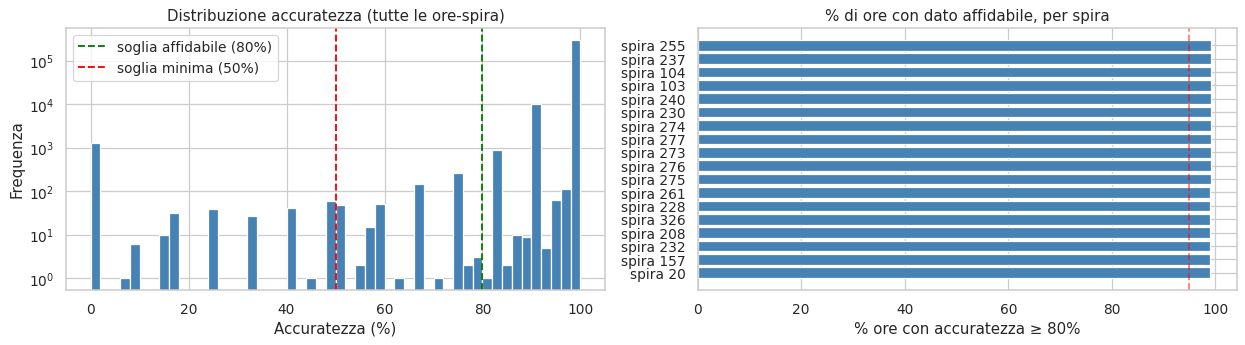

Distribuzione globale accuratezza:
count    314925.000000
mean         99.153033
std           6.919208
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
Name: accuratezza, dtype: float64

Ore-spira con acc ≥ 80%: 99.09%
Ore-spira con acc < 50%: 0.47%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Distribuzione globale dell'accuratezza.
axes[0].hist(df['accuratezza'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(80, color='green', linestyle='--', label='soglia affidabile (80%)')
axes[0].axvline(50, color='red', linestyle='--', label='soglia minima (50%)')
axes[0].set_title('Distribuzione accuratezza (tutte le ore-spira)')
axes[0].set_xlabel('Accuratezza (%)')
axes[0].set_ylabel('Frequenza')
axes[0].set_yscale('log')
axes[0].legend()

# (b) Percentuale ore affidabili per spira.
ratio_ok = (df.assign(ok=df['accuratezza'] >= 80)
              .groupby('chiave')['ok'].mean()
              .sort_values())
axes[1].barh(range(len(ratio_ok)), ratio_ok.values * 100, color='steelblue')
axes[1].set_yticks(range(len(ratio_ok)))
axes[1].set_yticklabels([f'spira {k}' for k in ratio_ok.index])
axes[1].axvline(95, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('% di ore con dato affidabile, per spira')
axes[1].set_xlabel('% ore con accuratezza ≥ 80%')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '07_qualita_dato.png', dpi=120)
plt.show()

print('Distribuzione globale accuratezza:')
print(df['accuratezza'].describe())
print()
print(f'Ore-spira con acc ≥ 80%: {(df["accuratezza"] >= 80).mean():.2%}')
print(f'Ore-spira con acc < 50%: {(df["accuratezza"] < 50).mean():.2%}')

## 8. Festività e tipo giorno

Verifichiamo che le tre categorie operative (feriale / weekend / festivo) abbiano profili effettivamente distinti, giustificando la scelta di includere `tipo_giorno` come feature condizionante.

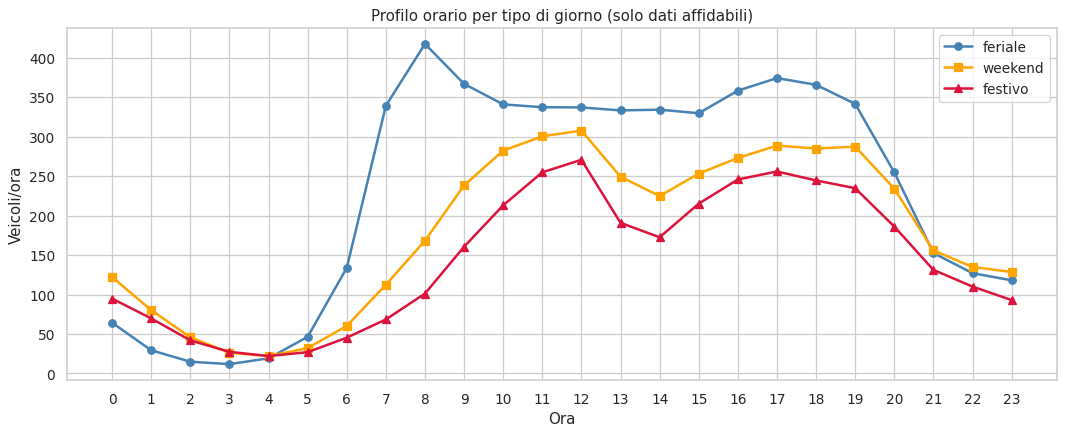

Distribuzione tipo_giorno (ore):
tipo_giorno
feriale    217728
weekend     85968
festivo     12096
Name: count, dtype: int64


In [11]:
profilo_tipo = (
    df[df['accuratezza'] >= 80]
      .groupby(['tipo_giorno', 'ora'])['conteggio_veicoli']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for tipo, marker, c in zip(['feriale', 'weekend', 'festivo'],
                            ['o', 's', '^'],
                            ['steelblue', 'orange', 'crimson']):
    sub = profilo_tipo[profilo_tipo['tipo_giorno'] == tipo]
    ax.plot(sub['ora'], sub['conteggio_veicoli'], marker=marker, label=tipo,
            color=c, linewidth=2)
ax.set_title('Profilo orario per tipo di giorno (solo dati affidabili)')
ax.set_xlabel('Ora')
ax.set_ylabel('Veicoli/ora')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '08_profilo_tipo_giorno.png', dpi=120)
plt.show()

print('Distribuzione tipo_giorno (ore):')
print(df['tipo_giorno'].value_counts())

## 9. Sintesi delle evidenze

Riassumiamo le scoperte rilevanti che guideranno la Fase 2.b:

| Evidenza | Implicazione modellistica |
|---|---|
| Distribuzione conteggio fortemente skewed, bimodale | Standardizzazione condizionata al contesto |
| Stagionalità settimanale forte (lun-ven vs sab-dom) | STL con periodo 168, `dow` come feature |
| Eteroschedasticità (std varia 10-30x per ora) | Soglie ora-dipendenti, score standardizzato |
| Stagionalità annuale visibile (Ago, Dic) | Includere `mese`, evitare di flaggare Ferragosto |
| Pioggia → ↓5-10% del flusso (variabile per ora) | Meteo come feature in B2 e B3 |
| Accuratezza > 80% per >99% delle ore-spira selezionate | Possibile lavorare quasi sempre con dato affidabile |
| Festivi hanno profilo distinto da feriali/weekend | `tipo_giorno` essenziale per non flaggare 1° gennaio |

**Prossimo step**: notebook 02 — implementazione delle tre baseline.